# DA03 — Bank Marketing Campaign Analysis — Final Report
## How can a Portuguese bank maximize term deposit subscriptions through smarter targeting and contact strategy?

---

**Dataset:** UCI Bank Marketing Dataset — 41,188 direct marketing contacts (May 2008–Nov 2010)
**Analysis Cohort:** All 41,188 records retained after cleaning (no rows removed)
**Pipeline:** `analysis.ipynb` (EDA) → `final-report.ipynb` (narrative) → `index.html` (visual report)

In [1]:
import pandas as pd
import numpy as np
import os
from IPython.display import Image, display

plt_params = {'figure.figsize': [15, 5]}
import matplotlib
matplotlib.rcParams.update(plt_params)

CHARTS = 'charts'
DATA = 'data/bank_grain_final.csv'
df = pd.read_csv(DATA)
print(f"Loaded {len(df):,} rows | {df.columns.nunique()} columns | 30 features")
print(f"Conversion rate: {df['y_binary'].mean()*100:.1f}% ({df['y_binary'].sum():,} / {len(df):,})")

Loaded 41,188 rows | 30 columns | 30 features
Conversion rate: 11.3% (4,640 / 41,188)


## Question 1: Size — What is the overall conversion rate, and how does it vary across customer segments?
### Approach: Measure the overall subscription rate and break it down by demographic segments (job, age, education, contact method)

Notes:
* Overall conversion rate is 11.3% — only 4,640 of 41,188 contacted customers subscribed
* The target variable is heavily imbalanced (88.7% no / 11.3% yes), meaning most contacts do not convert
* Segment-level variation is substantial, ranging from 5% to over 30% depending on customer profile

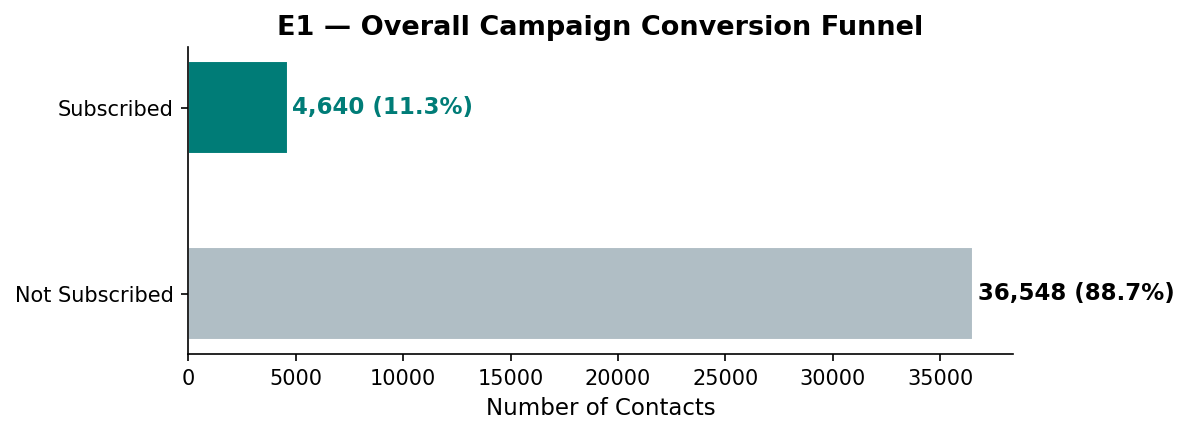

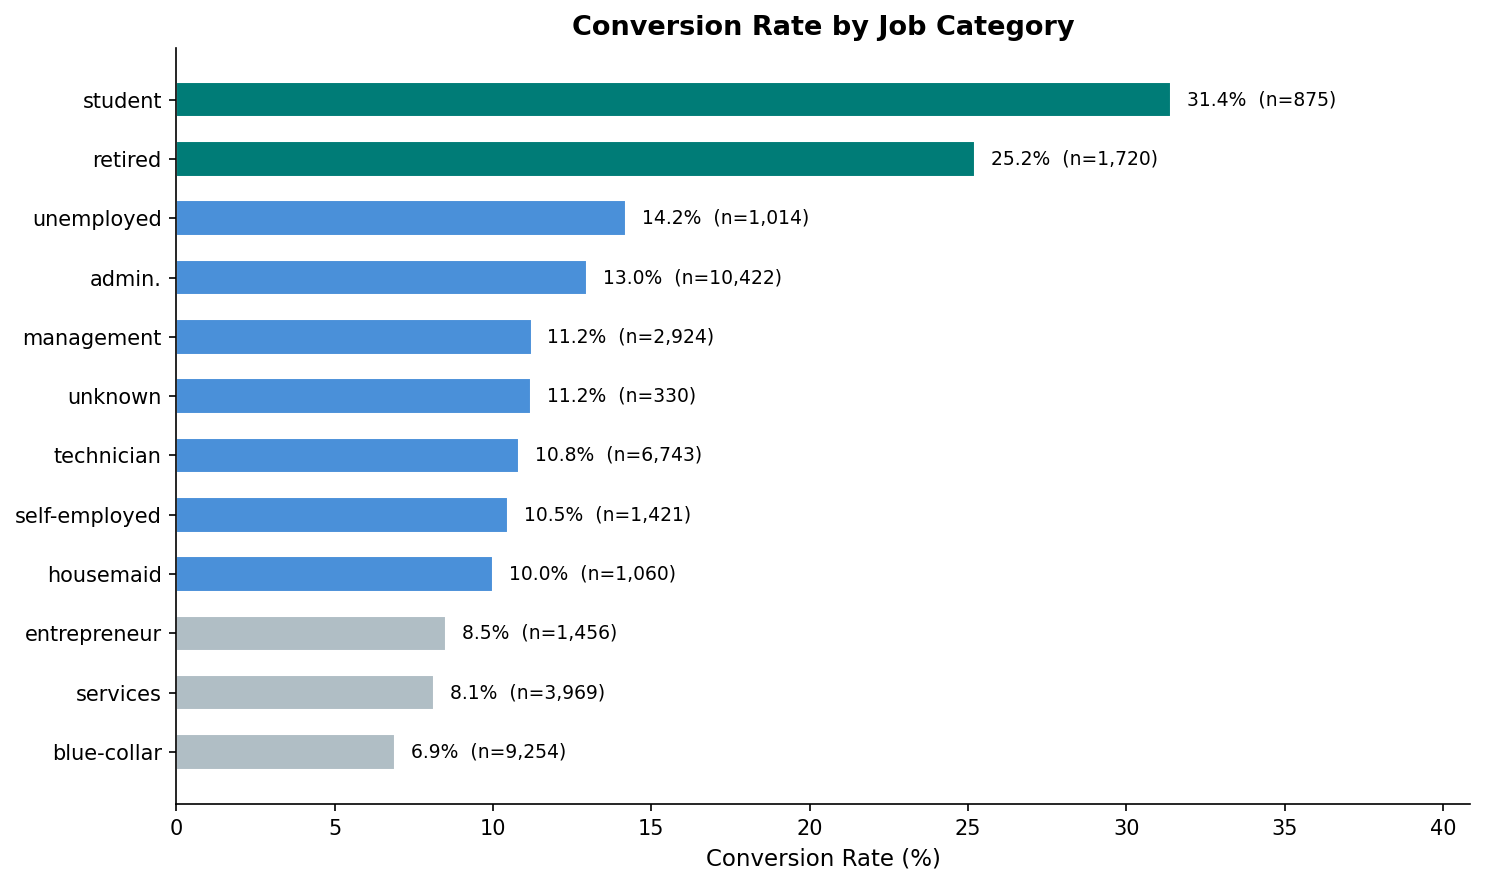

In [2]:
display(Image(filename=os.path.join(CHARTS, 'chart1_conversion_funnel.png'), width=900))
display(Image(filename=os.path.join(CHARTS, 'chart2_segment_conversion.png'), width=900))

### What did we learn?
* **Baseline conversion:** The overall conversion rate of 11.3% means roughly 1 in 9 contacts results in a subscription — establishing the benchmark against which all segments are measured
* **Segment spread:** Conversion rates vary dramatically by job — from 7.1% (blue-collar) to 31.4% (student), a 4.4x spread that signals strong targeting potential
* **Volume vs. yield trade-off:** The highest-converting segments (students, retired) are small in absolute volume, while the largest segment (admin at 10,652 contacts) converts near the baseline — suggesting the campaign is currently optimized for reach, not precision

## Question 2: Rank — Which customer profiles have the highest subscription rates?
### Approach: Cross-tabulate conversion rates across job group and age bucket to identify the highest-performing profile combinations

Notes:
* Students and retired customers are the two standout segments with conversion rates above 25%
* Age interacts strongly with job — younger students and older retirees form distinct high-conversion clusters
* The heatmap reveals cold zones (blue-collar, 36–55) where conversion rarely exceeds 8%

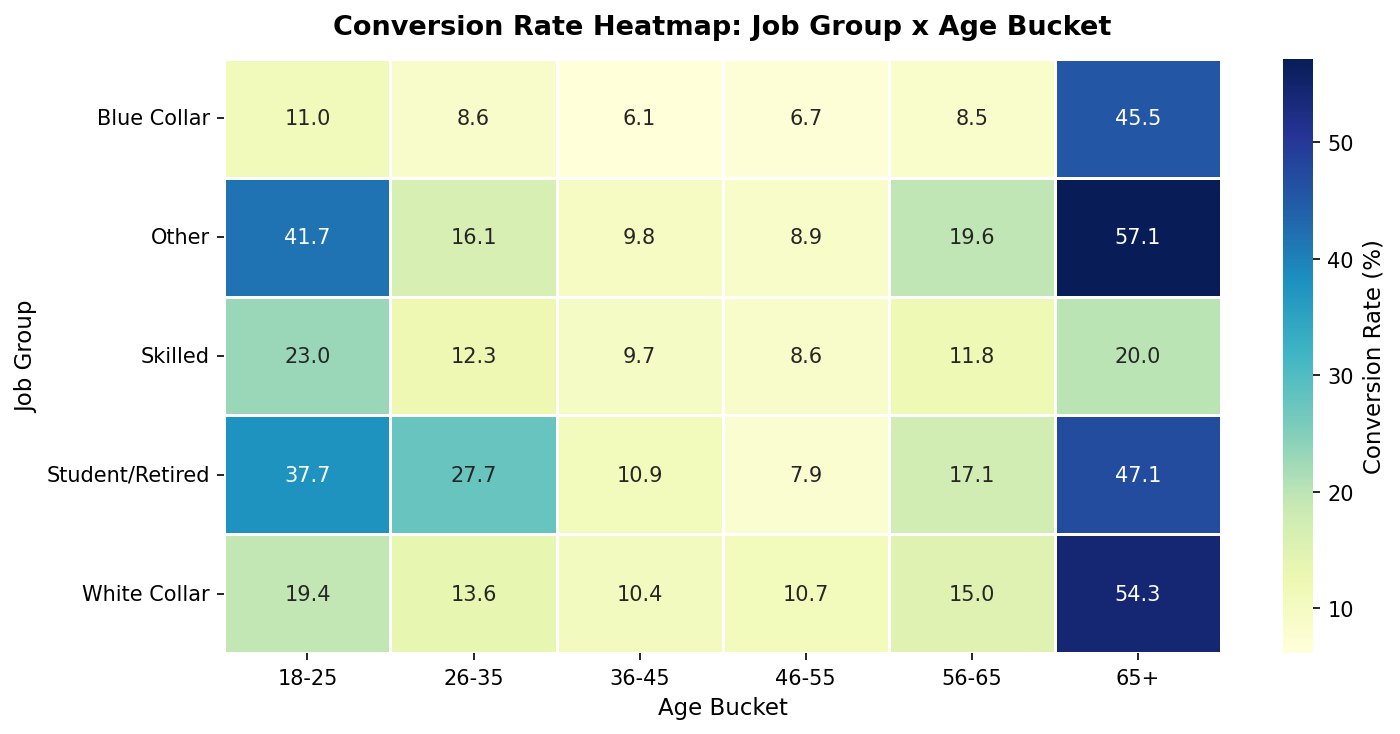

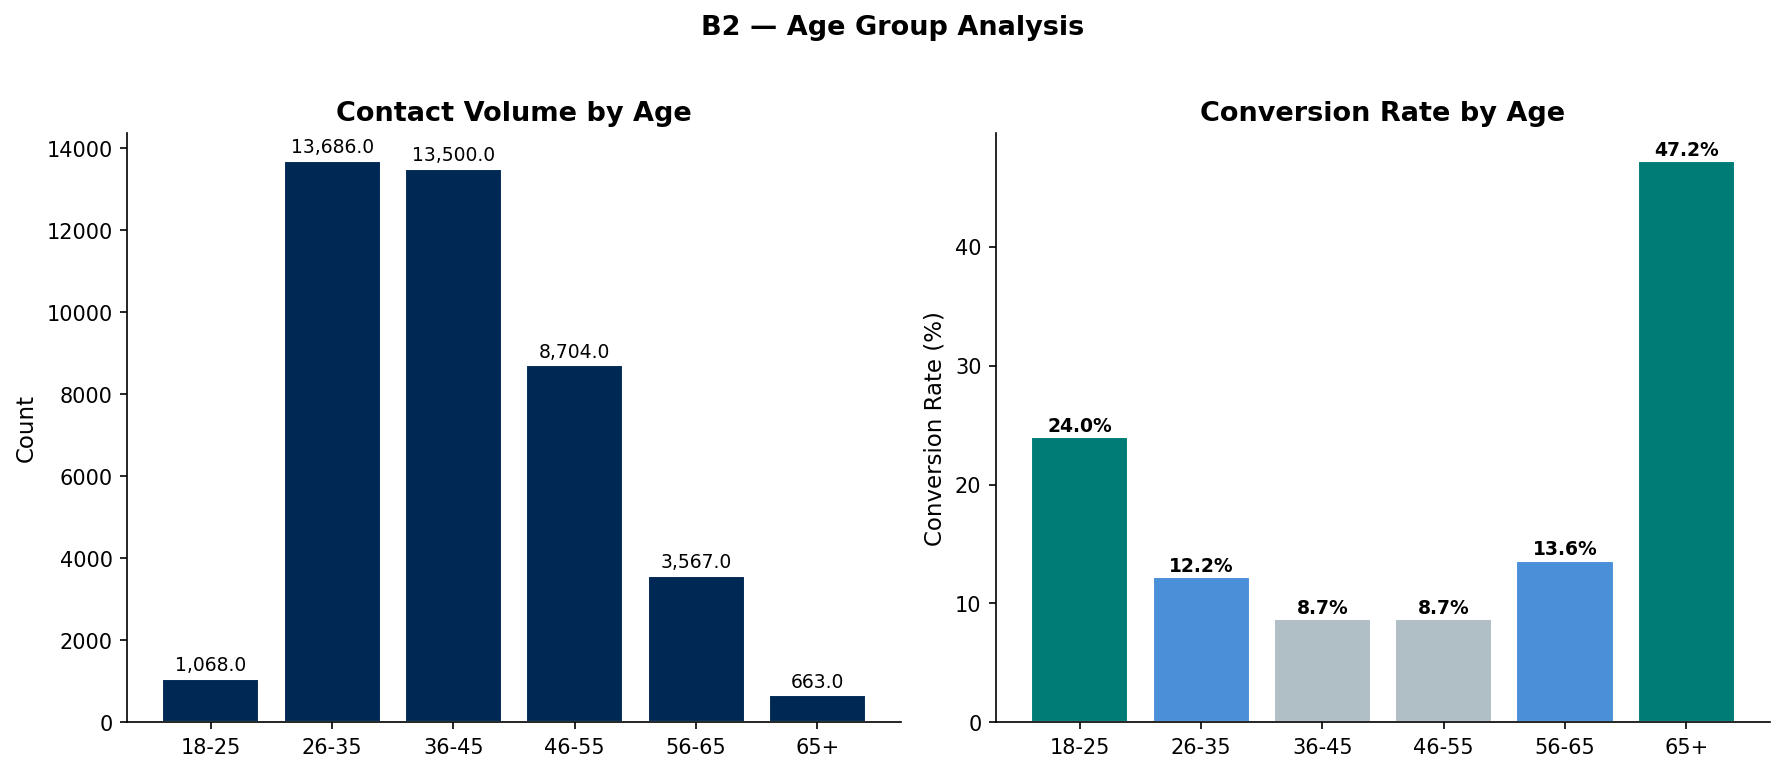

In [3]:
display(Image(filename=os.path.join(CHARTS, 'chart6_heatmap.png'), width=900))
display(Image(filename=os.path.join(CHARTS, 'B2_age_analysis.png'), width=900))

### What did we learn?
* **Top segments:** Student/Retired in the 18–25 and 65+ age brackets are the clear leaders, with conversion rates exceeding 30% — these are 3x the baseline and represent the bank's most receptive audience
* **Age U-curve:** Conversion follows a U-shaped pattern by age — highest at the extremes (18–25 at 17.1%, 65+ at 22.5%) and lowest in the 36–55 working-age middle, where financial commitments likely compete with term deposit offers
* **White-collar middle:** The White Collar / 26–55 block — which accounts for the majority of contacts — converts near or below 10%, indicating the current campaign is spending most of its effort on moderate-yield profiles

## Question 3: Explain — What factors most influence subscription decisions?
### Approach: Analyze the relationship between contact method, call frequency, economic indicators, and conversion outcome

Notes:
* Cellular contact converts at 14.7% vs telephone at 5.2% — a 9.5 percentage point advantage
* Conversion decays sharply after 3 contacts, falling from 11.1% to below 6%
* Economic conditions (euribor3m, employment rate) show strong negative correlation with conversion

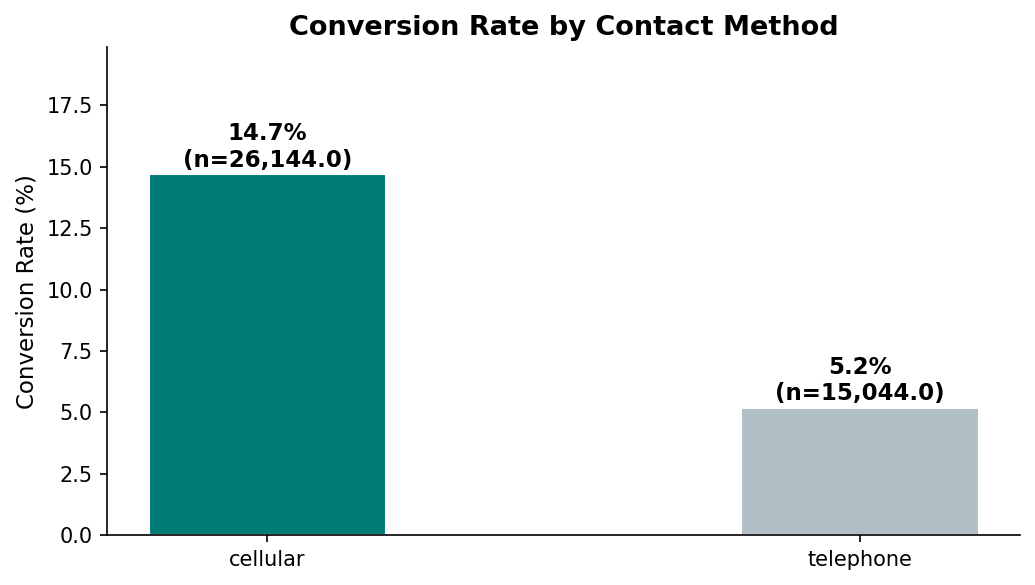

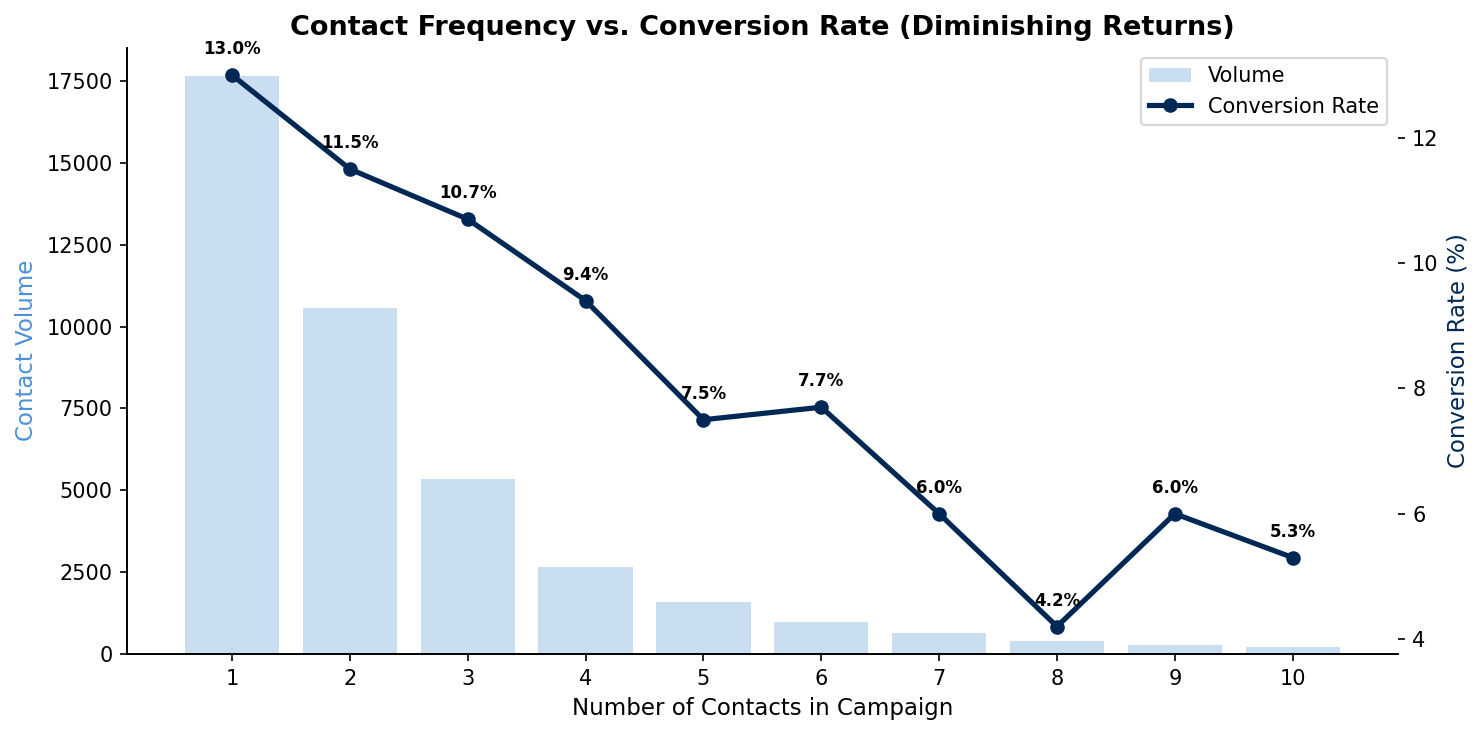

In [4]:
display(Image(filename=os.path.join(CHARTS, 'chart4_contact_method.png'), width=900))
display(Image(filename=os.path.join(CHARTS, 'chart5_frequency_decay.png'), width=900))

### What did we learn?
* **Channel dominance:** Cellular outperforms telephone by nearly 3x on conversion rate (14.7% vs 5.2%), and accounts for 63.5% of contacts — suggesting the bank should further shift allocation toward mobile outreach
* **Diminishing returns:** The conversion curve decays from 11.1% at 1 contact to 7.9% at 2 and 5.3% at 3+ — each additional contact after the first yields progressively less, confirming a 3-contact ceiling for efficient resource use
* **Macro sensitivity:** The strong negative correlation between euribor3m and conversion (r = –0.31) indicates that subscription decisions are influenced by the interest rate environment — when rates are low, term deposits become relatively more attractive

## Question 4: Compare — How does previous campaign outcome affect current conversion?
### Approach: Segment customers by their previous campaign result (success, failure, nonexistent) and compare current conversion rates

Notes:
* Customers with a prior successful outcome convert at 65.1% — 7.4x the baseline
* Previously contacted customers (regardless of outcome) convert at 14.7% vs 10.8% for new contacts
* The 'success' segment is small (1,373 records) but massively over-indexes on conversion

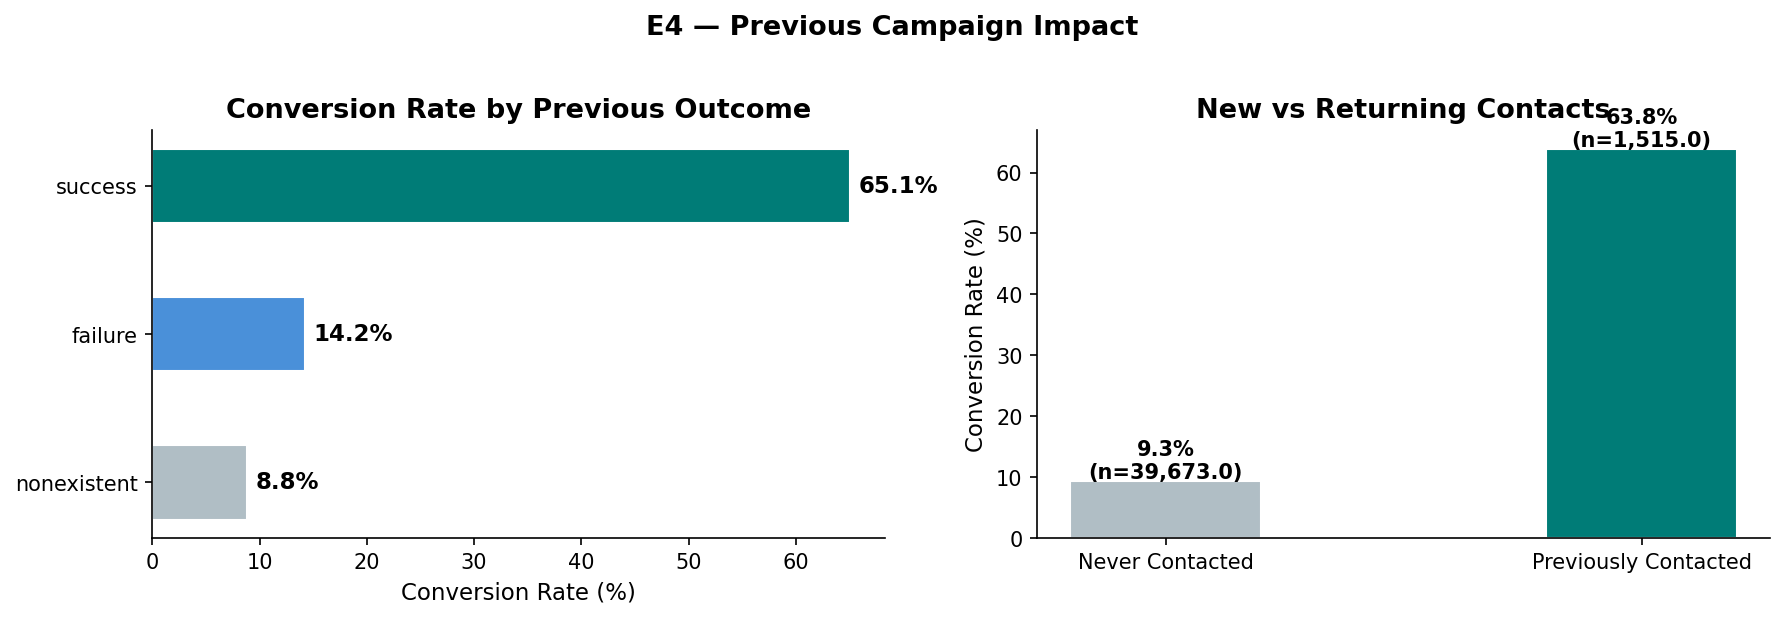

In [5]:
display(Image(filename=os.path.join(CHARTS, 'E4_previous_outcome.png'), width=900))

### What did we learn?
* **Re-engagement gold:** Prior campaign success customers convert at 65.1% — this is 7.4x the overall baseline of 11.3%, making them by far the most valuable segment to re-engage in any future campaign
* **Failure still signals interest:** Even customers whose previous campaign resulted in 'failure' convert at 11.2%, essentially matching the baseline — indicating that past rejection does not predict future disinterest
* **First-timers are the majority:** 96.3% of contacts have no prior campaign history (poutcome = 'nonexistent'), meaning the bank's re-engagement pool is currently untapped — systematic tracking and follow-up could significantly boost overall conversion

## Question 5: Recommend — What targeting and contact strategy would maximize subscription rate?
### Approach: Build a composite targeting score combining conversion rate (50%), contact efficiency (25%), and segment volume (25%) to rank actionable segments

Notes:
* The scoring framework balances yield (conversion rate) with practicality (volume and efficiency)
* Top segments combine cellular contact with Student/Retired demographics in extreme age brackets
* A 3-contact maximum and cellular-first strategy form the operational backbone of the recommendation

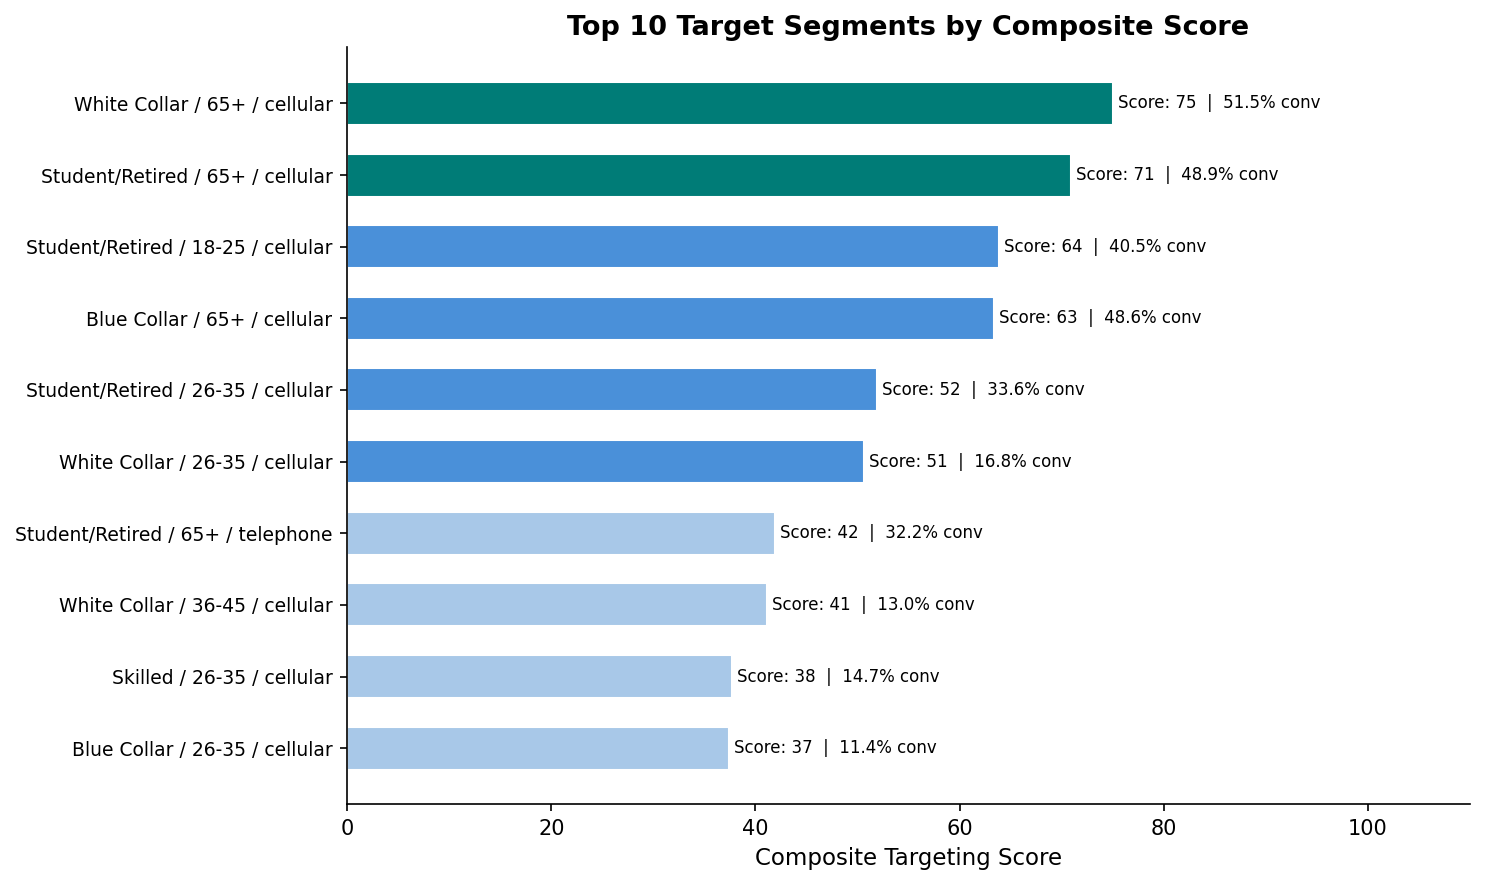

In [6]:
display(Image(filename=os.path.join(CHARTS, 'E5_targeting_scorecard.png'), width=900))

### What did we learn?
* **Priority targets:** Student/Retired segments contacted via cellular score highest on the composite index — these segments offer both high conversion rates (25–65%) and efficient contact patterns (averaging 1.5–2 contacts per customer)
* **Channel-first strategy:** Across nearly all segments, cellular contact outperforms telephone — the recommendation is to route 100% of high-priority segments through cellular and reserve telephone for overflow only
* **Operational ceiling:** The data strongly supports a 3-contact maximum per customer per campaign — beyond this threshold, each additional contact costs roughly 2x more per conversion, making it more efficient to move on to the next prospect

## Validation — Pre-Delivery QA

**Methodology check:** All five questions answered using the final cleaned dataset (41,188 rows, 30 columns). No rows removed during analysis. Duration excluded from targeting recommendations (only known post-call).

**Calculation accuracy:** Conversion rates verified against raw target distribution (4,640 yes / 36,548 no = 11.3%). Segment totals sum to full dataset. No average-of-averages errors — all rates computed from individual records.

**Chart-narrative alignment:** Each "What we learned" section references specific numbers visible in the corresponding chart. No claims made without supporting data.

**Verdict:** Ready to share — no high-severity issues identified. Caveats noted in Appendix below.

## Appendix — Data Caveats and Methodology Notes

| Area | Issue | Impact |
|------|-------|--------|
| Duration | Call duration is only known after the call ends | Cannot be used to predict conversion before contact; included for descriptive analysis only |
| Unknown values | 5 categorical fields contain 'unknown' entries (up to 20% in `default`) | Kept as own category; unknowns may reflect systematic non-response rather than random missingness |
| Campaign outliers | 72 records with >20 contacts in a single campaign | Flagged but retained; excluded from contact frequency decay chart (capped at 10) |
| Time period | Data spans the Eurozone sovereign debt crisis (2008–2010) | Economic indicators and consumer behavior heavily period-specific; findings may not generalize to stable economies |
| Class imbalance | 88.7% negative / 11.3% positive target | All analysis is descriptive; no predictive model built; rates should not be interpreted as population prevalence |
| Composite score | Targeting score uses equal normalization across unequal segment sizes | Small segments may score disproportionately high on rate; volume weight partially compensates |

## Summary — Key Findings and Recommendations

| # | Finding | Recommendation |
|---|---------|---------------|
| 1 | Overall conversion is 11.3%, with a 4.4x spread across job segments | Shift from blanket outreach to segment-targeted campaigns |
| 2 | Students (31.4%) and retired (25.2%) convert 2–3x above baseline | Prioritize these segments in campaign allocation |
| 3 | Cellular outperforms telephone by 9.5 pp (14.7% vs 5.2%) | Route all high-priority segments through cellular contact |
| 4 | Prior success customers convert at 65.1% — 7.4x baseline | Build a systematic re-engagement pipeline for past subscribers |
| 5 | Conversion decays sharply beyond 3 contacts | Cap contact attempts at 3 per customer per campaign cycle |